In [1]:
import torch
from torch import nn
import torch.optim as optim

%matplotlib inline
torch.set_printoptions(sci_mode=False,precision=4)
torch.manual_seed(1234)
torch.random.manual_seed(1234)
generator = torch.Generator().manual_seed(1234)

In [2]:
context_length = 3
batch_size = 1
embd_dim = 2
iteration_count = 200
head_size = 2

In [3]:
# m -> 1, 2, 5, 6, 9
# f -> 3, 4, 7, 8
# x_numpy = ['b1m','m2b','g3f','f4g','m5b','b6m','g7f','b9m','f8g']
# y_numpy = ['C','C','B','B','C','C','B','C','B']

x_numpy = ['b1m']
y_numpy = ['C']

In [4]:
unique_text = list(sorted(set(''.join(x_numpy))))

unique_y_text = ['B', 'C']

VOCAB_INPUT_SIZE = len(unique_text)
print(VOCAB_INPUT_SIZE)

label_vocab = sorted(set(y_numpy))
VOCAB_OUTPUT_SIZE = len(unique_y_text)

3


In [5]:
stoi = {text: index for index, text in enumerate(unique_text)}
itos = {index: text for index, text in enumerate(unique_text)}

encoder = lambda char_array: [stoi[char] for char in ''.join(char_array)]
decoder = lambda num_array: [itos[num] for num in num_array]

print(stoi)

{'1': 0, 'b': 1, 'm': 2}


In [6]:
x_train = []
y_train = []

for x,y in zip(x_numpy,y_numpy):
    x_train.append(encoder(x))
    y_train.append(0 if y == 'B' else 1)

x_train = torch.tensor(x_train)
y_train = torch.tensor(y_train)

# print(x_train.shape)
# print(y_train.shape)

In [7]:
criterion = nn.CrossEntropyLoss()
embedding = nn.Embedding(VOCAB_INPUT_SIZE, embd_dim) # Assuming vocab_size is defined
logit_layer = nn.Linear(embd_dim * context_length, VOCAB_OUTPUT_SIZE, bias= False) # Adjusted input size

In [8]:
# --- Optimizer ---
# Note: embedding and logit_layer should be in .train() mode for training
optimizer = optim.Adam([
    {'params': list(embedding.parameters()), 'lr': 0.01},
    {'params': list(logit_layer.parameters()), 'lr': 0.001}
], lr=0.001)

In [9]:
print(stoi)
print(embedding.weight)
print(logit_layer.weight)

embedding_params = sum(p.numel() for p in embedding.parameters() if p.requires_grad)
logit_params = sum(p.numel() for p in logit_layer.parameters() if p.requires_grad)

print(logit_params)

{'1': 0, 'b': 1, 'm': 2}
Parameter containing:
tensor([[ 0.0461,  0.4024],
        [-1.0115,  0.2167],
        [-0.6123,  0.5036]], requires_grad=True)
Parameter containing:
tensor([[ 0.2244,  0.2619, -0.1802,  0.1484, -0.1766,  0.1280],
        [-0.2133,  0.1888,  0.0826, -0.1598, -0.2002,  0.1056]],
       requires_grad=True)
12


tensor([[-1.0115,  0.2167,  0.0461,  0.4024, -0.6123,  0.5036]],
       grad_fn=<ViewBackward0>)
logits :  tensor([[0.0538, 0.3720]], grad_fn=<MmBackward0>)
y_train :  tensor([1])
0.5466241836547852


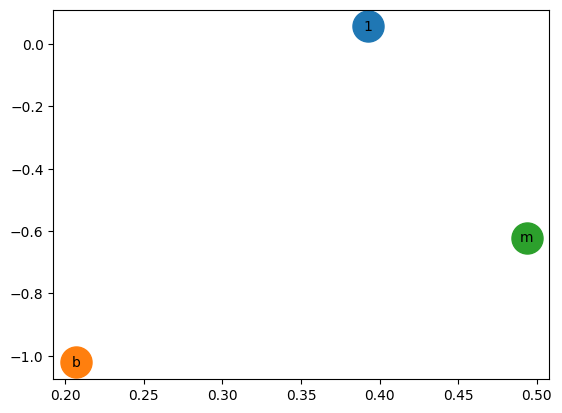

In [10]:
for epoch in range(1):
    # 1. Data Fetching
    optimizer.zero_grad(set_to_none=True)

    tok_emb = embedding(x_train)
    pos = torch.arange(3)
    x = tok_emb

    out_flattened = x.view(batch_size, -1)

    print(out_flattened)

    logits = logit_layer(out_flattened)
    print('logits : ', logits)
    print('y_train : ', y_train)
    loss = criterion(logits, y_train)

    if epoch % 10 == 0:
        # print(embedding.weight)
        print(loss.item())

    loss.backward()
    optimizer.step()

import matplotlib.pyplot as plt
%matplotlib inline
first = embedding.weight[:, 1].detach().float().cpu().numpy()
second = embedding.weight[:, 0].detach().float().cpu().numpy()
for i in range(len(first)):
    word = itos[i]
    plt.scatter(first[i], second[i], s=500)
    plt.text(first[i], second[i], word, fontsize=10, ha='center', va='center')

In [ ]:
eval = torch.tensor(encoder('b5m'))
tok_emb = embedding(eval)
pos = torch.arange(3)
x = tok_emb


out_flattened = x.view(-1)
print(out_flattened.shape)

logits = logit_layer(out_flattened)
print(logits)
print(embedding.weight)

In [32]:
_emb_ = torch.tensor([
    [-1.0115,  0.2167],
    [ 0.0461,  0.4024],
    [-0.6123,  0.5036]
])

_emb_ = _emb_.view(1, -1)

_logit_layer_ = torch.tensor([[ 0.2244,  0.2619, -0.1802,  0.1484, -0.1766,  0.1280],
        [-0.2133,  0.1888,  0.0826, -0.1598, -0.2002,  0.1056]])

logits = _emb_ @ _logit_layer_.t()

correct_class = 1

print(logits)

z_y = logits[0, correct_class]

L = -z_y + torch.log(torch.sum(torch.exp(logits)))

print(L)

tensor([[0.0538, 0.3719]])
tensor(0.5467)
